# import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and explore the dataset

In [2]:
df=pd.read_csv('/content/sample_data/placementforsimpleRegre.csv')
df.head(8)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
5,7.89,2.99
6,6.73,2.60
7,6.75,2.48


In [4]:
df.isnull().sum()

,0
cgpa,0
package,0


## view the data linearity

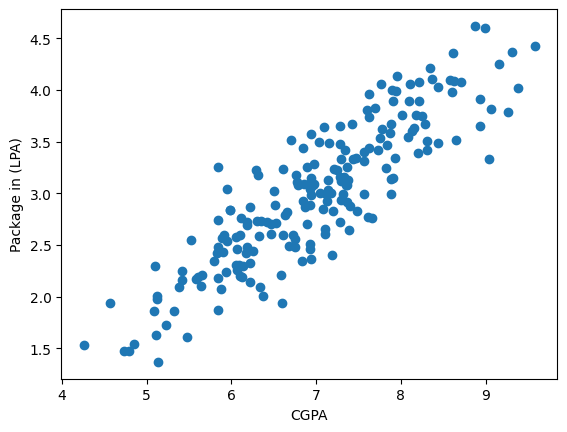

In [5]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package in (LPA)')
plt.show()

# 2. seperate tar & feature col

In [12]:
X=df.iloc[:,0:1] # all rows & first column
y=df.iloc[:,-1] #all rows & last column

print(X)
print(y)

     cgpa
0    6.89
1    5.12
2    7.82
3    7.42
4    6.94
..    ...
195  6.93
196  5.89
197  7.21
198  7.63
199  6.22

[200 rows x 1 columns]
0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64


# splitting the data

In [13]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets (80% train, 20% test)
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42)


In [14]:
X_train

,cgpa
79,7.18
197,7.21
38,8.62
24,6.53
122,5.12
...,...
106,6.13
14,7.73
92,7.90
179,7.14


In [18]:
X_test

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


# Train the Simple Linear Regression Model

 > Now we can create a Linear Regression model using scikit-learn and train it on the training data. The model will calculate the intercept (𝛽0) and coefficient (𝛽1) of the linear equation.






In [19]:
from sklearn.linear_model import LinearRegression
#create a linear regression model
model = LinearRegression()

#train the model on training data
model.fit(X_train,y_train)


LinearRegression()

## intercept & coefficient

 > **Learned parameter**

In [20]:
print(f"Intercept : {model.intercept_}")
print(f"Coefficient : {model.coef_}")

Intercept : -1.0270069374542108
Coefficient : [0.57425647]


# Make prediction

In [21]:
# predict the dependent variable
y_pred = model.predict(X_test)

#Display predictions and actual value

predictions = pd.DataFrame({'Actual':y_test,
                            'predict':y_pred})

predictions.head(7)

,Actual,predict
95,2.79,2.780313
15,3.23,3.136352
30,3.26,3.199521
158,3.04,2.389819
128,3.34,3.526847
115,4.21,3.768035
69,2.94,3.165065


# Visualize Regression line

 > A good way to understand the relationship between the predicted and actual data is to visualize it. We'll plot the regression line along with the actual data points.

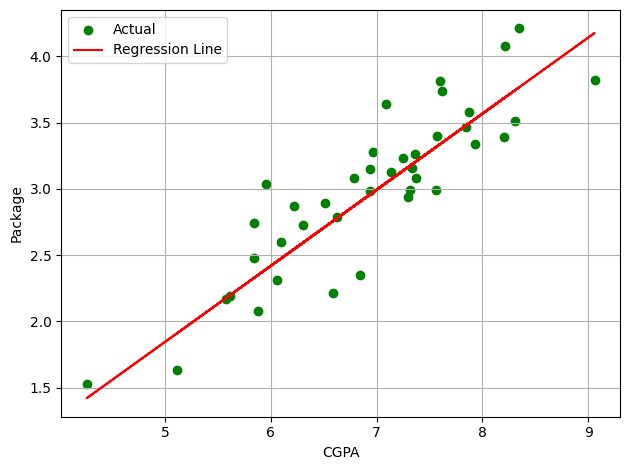

In [23]:
#plot the actual data points
plt.scatter(X_test,y_test,color='green',label='Actual')

#plot the regression line
plt.plot(X_test,y_pred,color='red',label='Regression Line')
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()